# PCOS Survey EDA — Enhanced Visualisation Edition

## Introduction
This notebook keeps the same survey analysis but uses clearer and more varied charts. Each question uses a different chart type so the notebook is easier to read.

| Question | Old chart | New chart |
|---|---|---|
| Q1 — target balance | countplot | **Donut chart + centre annotation** |
| Q2 — age | violin + strip | **Raincloud plot (half-violin + jittered dots + boxplot)** |
| Q3 — BMI | violin + strip | **KDE ridgeline (overlapping densities)** |
| Q4 — cycle regularity | barplot | **Lollipop / diverging chart** |
| Q5 — cycle length | boxenplot + strip | **Sina / beeswarm scatter** |
| Q6 — months between periods | ECDF | **Annotated ECDF with shaded gap** |
| Q7 — period duration | boxenplot + strip | **Split half-violin** |
| Q8–Q12 — 5 binary symptoms | 5 × barplot | **Grouped dot-matrix heatmap panel** |
| Q13–Q15 — lifestyle / mood | 3 × barplot | **Horizontal paired bar diverging chart** |
| Q16 — burden score | histogram | **Filled KDE area chart** |


## Setup and File Paths


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from scipy.stats import gaussian_kde
from IPython.display import display

np.random.seed(42)

# ── Global style ──────────────────────────────────────────────────────────────
FONT_FAMILY = "DejaVu Sans"
mpl.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 10,
    "axes.labelcolor": "#3d3d3d",
    "axes.edgecolor": "#cccccc",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "font.family": FONT_FAMILY,
})

# ── Colour system ─────────────────────────────────────────────────────────────
NEG_COLOR  = "#4C72B0"   # blue  — PCOS Negative
POS_COLOR  = "#DD6B3B"   # burnt-orange — PCOS Positive
NEG_LIGHT  = "#a8c0e8"
POS_LIGHT  = "#f0b898"
PCOS_LABEL_ORDER   = ["PCOS Negative", "PCOS Positive"]
PCOS_LABEL_PALETTE = {"PCOS Negative": NEG_COLOR, "PCOS Positive": POS_COLOR}

# ── Paths ─────────────────────────────────────────────────────────────────────
def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, current.parent, current.parent.parent]:
        if (candidate / "cleaned_data").exists() and (candidate / "images").exists():
            return candidate
    return current

PROJECT_ROOT = resolve_project_root()
DATA_PATH    = PROJECT_ROOT / "cleaned_data" / "PCOS_survey_cleaned.csv"
IMAGE_DIR    = PROJECT_ROOT / "images" / "eda" / "survey_enhanced"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig: plt.Figure, slug: str) -> None:
    fig.savefig(IMAGE_DIR / slug, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

def grouped_numeric_summary(data, feature):
    return (
        data.groupby("pcos_label")[feature]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n"})
        .round(3)
        .reset_index()
    )

def grouped_binary_prevalence(data, feature):
    summary = (
        data.groupby("pcos_label")[feature]
        .agg(["count", "sum", "mean"])
        .rename(columns={"count": "n", "sum": "positive_count", "mean": "prevalence"})
        .reset_index()
    )
    summary["prevalence_pct"] = (summary["prevalence"] * 100).round(1)
    return summary[["pcos_label", "n", "positive_count", "prevalence_pct"]]

print("Setup complete.")

Setup complete.


## Load Data and Add Survey Features


In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = [
    "pcos_y_n", "age_yrs", "weight_kg", "height_cm", "bmi",
    "cycle_regularity", "cycle_length_days", "months_between_periods",
    "period_duration_days", "weight_gain_y_n", "hair_growth_y_n",
    "skin_darkening_y_n", "hair_loss_y_n", "pimples_y_n",
    "fast_food_y_n", "regular_exercise_y_n", "mood_swings_y_n",
]
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing: {missing}")

for col in required_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

binary_cols = [
    "pcos_y_n", "cycle_regularity", "weight_gain_y_n", "hair_growth_y_n",
    "skin_darkening_y_n", "hair_loss_y_n", "pimples_y_n",
    "fast_food_y_n", "regular_exercise_y_n", "mood_swings_y_n",
]
for col in binary_cols:
    df[col] = df[col].astype(int)

df["pcos_label"]            = df["pcos_y_n"].map({0: "PCOS Negative", 1: "PCOS Positive"})
df["low_exercise_flag"]     = (1 - df["regular_exercise_y_n"]).astype(int)
df["irregular_cycle_flag"]  = (1 - df["cycle_regularity"]).astype(int)
df["non_invasive_burden_score"] = (
    df["weight_gain_y_n"] + df["hair_growth_y_n"] + df["skin_darkening_y_n"]
    + df["hair_loss_y_n"] + df["pimples_y_n"] + df["fast_food_y_n"]
    + df["low_exercise_flag"] + df["irregular_cycle_flag"]
)

display(df.head())
print(f"Shape: {df.shape}  |  PCOS+ : {df.pcos_y_n.sum()}  |  PCOS- : {(df.pcos_y_n==0).sum()}")

,age_yrs,weight_kg,height_raw,blood_group_code,months_between_periods,weight_gain_y_n,hair_growth_y_n,skin_darkening_y_n,hair_loss_y_n,pimples_y_n,...,periods_regular_y_n,period_duration_days,height_cm,cycle_regularity,cycle_length_days,bmi,pcos_label,low_exercise_flag,irregular_cycle_flag,non_invasive_burden_score
0,21,47.0,168.0,13,1,0,0,0,0,0,...,1,6.0,168.0,1,30,16.652494,PCOS Negative,1,0,1
1,21,45.0,156.0,11,1,0,0,1,1,1,...,1,4.0,156.0,1,30,18.491124,PCOS Negative,1,0,4
2,17,37.0,162.0,15,1,0,0,0,0,1,...,1,6.0,162.0,1,30,14.098461,PCOS Negative,1,0,3
3,28,54.0,160.0,15,1,0,0,0,0,0,...,1,4.0,160.0,1,30,21.093750,PCOS Negative,1,0,1
4,45,40.0,150.0,13,2,0,0,0,1,0,...,0,7.0,150.0,0,60,17.777778,PCOS Positive,1,1,3


Shape: (464, 24)  |  PCOS+ : 101  |  PCOS- : 363


---
## Q1 — Survey Target Distribution
**Chart type: Donut chart with centre annotation and count labels**


,pcos_label,count,pct
0,PCOS Negative,363,78.2
1,PCOS Positive,101,21.8


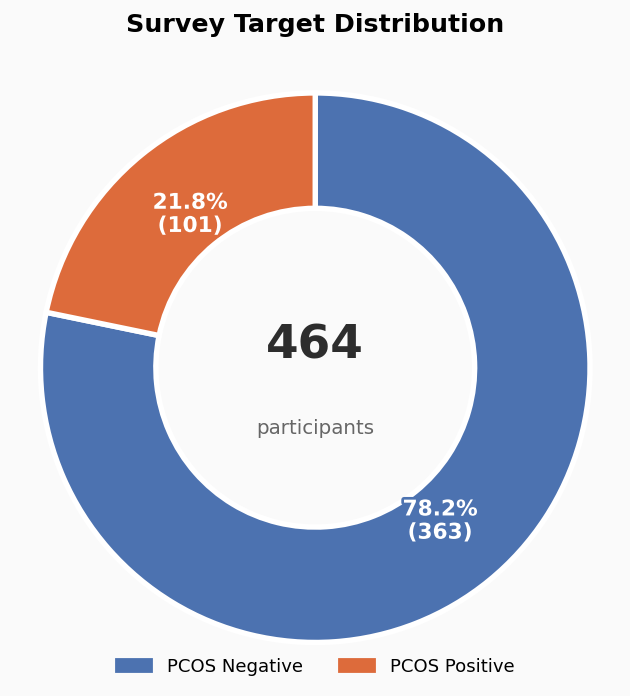

In [3]:
target_q01 = (
    df["pcos_label"]
    .value_counts()
    .reindex(PCOS_LABEL_ORDER)
    .reset_index()
)
target_q01.columns = ["pcos_label", "count"]
target_q01["pct"] = (100 * target_q01["count"] / target_q01["count"].sum()).round(1)
display(target_q01)

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor("#FAFAFA")

wedge_props = dict(width=0.42, edgecolor="white", linewidth=3)
wedges, texts = ax.pie(
    target_q01["count"],
    labels=None,
    colors=[NEG_COLOR, POS_COLOR],
    startangle=90,
    wedgeprops=wedge_props,
    counterclock=False,
)

# Centre annotation
total = target_q01["count"].sum()
ax.text(0, 0.08, str(total), ha="center", va="center", fontsize=26, fontweight="bold", color="#2d2d2d")
ax.text(0, -0.22, "participants", ha="center", va="center", fontsize=11, color="#666666")

# Callout labels
for i, (wedge, row) in enumerate(zip(wedges, target_q01.itertuples())):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.72 * np.cos(np.deg2rad(angle))
    y = 0.72 * np.sin(np.deg2rad(angle))
    color = [NEG_COLOR, POS_COLOR][i]
    ax.text(x, y, f"{row.pct:.1f}%\n({row.count:,})",
            ha="center", va="center", fontsize=12, fontweight="bold",
            color="white",
            path_effects=[pe.withStroke(linewidth=3, foreground=color)])

legend_patches = [
    mpatches.Patch(color=c, label=l)
    for l, c in PCOS_LABEL_PALETTE.items()
]
ax.legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.04),
          ncol=2, frameon=False, fontsize=10)

ax.set_title("Survey Target Distribution", fontsize=14, fontweight="bold", pad=20)
ax.axis("equal")
save_fig(fig, "q01_survey_target_distribution.png")
plt.show()

### Insight
**Scientific interpretation:** The donut chart shows a more imbalanced survey cohort than the clinical notebook, with 363 PCOS-negative respondents and 101 PCOS-positive respondents. That means the positive class is present but clearly smaller in this self-reported dataset.

**Simple summary:** The survey has many more negative cases than positive cases.

**Why this matters:** All later prevalence and distribution comparisons should be interpreted with the understanding that this is a noisier and more imbalanced outside-style validation source.


---
## Q2 — Age by PCOS Status
**Chart type: Raincloud plot (half-violin + jittered strip + embedded boxplot)**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,25.617,22.0,8.394,15,58
1,PCOS Positive,101,24.921,23.0,6.984,13,47


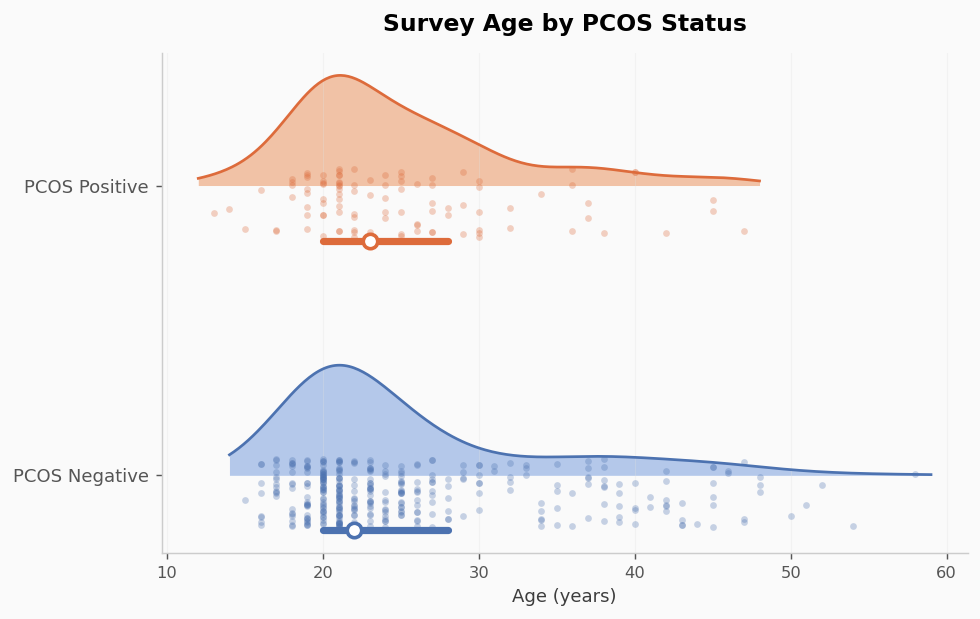

In [4]:
summary_q02 = grouped_numeric_summary(df, "age_yrs")
display(summary_q02)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#FAFAFA")

colors = [NEG_COLOR, POS_COLOR]
light_colors = [NEG_LIGHT, POS_LIGHT]

for i, label in enumerate(PCOS_LABEL_ORDER):
    y_pos = i
    subset = df.loc[df["pcos_label"] == label, "age_yrs"].dropna().values
    color = colors[i]
    lcolor = light_colors[i]

    # Half violin (upper half only)
    kde = gaussian_kde(subset, bw_method=0.35)
    x_range = np.linspace(subset.min() - 1, subset.max() + 1, 300)
    kde_vals = kde(x_range)
    kde_vals = kde_vals / kde_vals.max() * 0.38   # normalise height
    ax.fill_between(x_range, y_pos, y_pos + kde_vals,
                    color=lcolor, alpha=0.85, linewidth=0)
    ax.plot(x_range, y_pos + kde_vals, color=color, lw=1.5)

    # Jittered strip below
    jitter = np.random.uniform(-0.12, 0.12, size=len(subset))
    ax.scatter(subset, y_pos - 0.06 + jitter,
               color=color, alpha=0.30, s=14, linewidths=0, zorder=2)

    # Tiny boxplot
    q1, med, q3 = np.percentile(subset, [25, 50, 75])
    ax.plot([q1, q3], [y_pos - 0.19, y_pos - 0.19], lw=4, color=color, solid_capstyle="round")
    ax.plot([med], [y_pos - 0.19], marker="o", ms=8, color="white",
            markeredgecolor=color, markeredgewidth=2, zorder=5)

ax.set_yticks(range(len(PCOS_LABEL_ORDER)))
ax.set_yticklabels(PCOS_LABEL_ORDER, fontsize=10)
ax.set_xlabel("Age (years)", fontsize=10)
ax.set_title("Survey Age by PCOS Status", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["left", "bottom"]].set_visible(True)
ax.spines[["top", "right"]].set_visible(False)

save_fig(fig, "q02_age_vs_pcos_survey.png")
plt.show()

### Insight
**Scientific interpretation:** The half-violin and jittered points show heavy overlap in age, and the group means differ only slightly. Age is therefore acting more as background context than as a clear survey separator.

**Simple summary:** Age barely separates the survey groups.

**Why this matters:** This suggests that later non-invasive survey modelling should not rely heavily on age as a primary screening feature.


---
## Q3 — BMI by PCOS Status
**Chart type: Overlapping KDE ridgeline with mean annotation**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,23.073,22.491,4.361,13.388,51.129
1,PCOS Positive,101,25.097,24.595,4.709,14.199,40.904


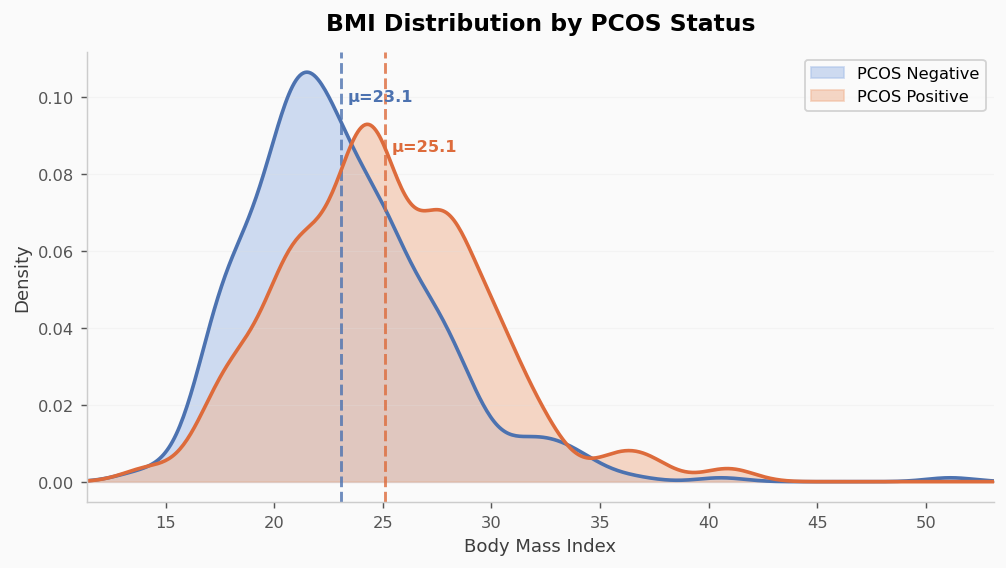

In [5]:
summary_q03 = grouped_numeric_summary(df, "bmi")
display(summary_q03)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("#FAFAFA")

palette = {"PCOS Negative": (NEG_COLOR, NEG_LIGHT),
           "PCOS Positive": (POS_COLOR, POS_LIGHT)}

for label in PCOS_LABEL_ORDER:
    subset = df.loc[df["pcos_label"] == label, "bmi"].dropna().values
    solid, light = palette[label]
    kde = gaussian_kde(subset, bw_method=0.25)
    x_range = np.linspace(df["bmi"].min() - 2, df["bmi"].max() + 2, 500)
    kde_vals = kde(x_range)
    ax.fill_between(x_range, 0, kde_vals, color=light, alpha=0.55, label=label)
    ax.plot(x_range, kde_vals, color=solid, lw=2)
    mean_val = subset.mean()
    ax.axvline(mean_val, color=solid, lw=1.6, ls="--", alpha=0.8)
    ax.text(mean_val + 0.3, kde_vals.max() * 0.96,
            f"μ={mean_val:.1f}", color=solid, fontsize=9, va="top", fontweight="bold")

ax.set_xlabel("Body Mass Index", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("BMI Distribution by PCOS Status", fontsize=13, fontweight="bold")
ax.legend(frameon=True, loc="upper right")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(df["bmi"].min() - 2, df["bmi"].max() + 2)

save_fig(fig, "q03_bmi_vs_pcos_survey.png")
plt.show()

### Insight
**Scientific interpretation:** The BMI density plot shifts to the right for the PCOS-positive group and also broadens, indicating both higher central tendency and wider spread. The pattern is not perfectly clean, but it clearly moves in the same direction as the clinical notebook.

**Simple summary:** BMI is higher overall in the PCOS-positive survey group.

**Why this matters:** This is important because it shows that the adiposity signal survives even when the data are self-reported and noisier than the clinical cohort.


---
## Q4 — Cycle Regularity Prevalence
**Chart type: Lollipop chart with percentage labels**


,pcos_label,n,positive_count,prevalence_pct
0,PCOS Negative,363,328,90.4
1,PCOS Positive,101,37,36.6


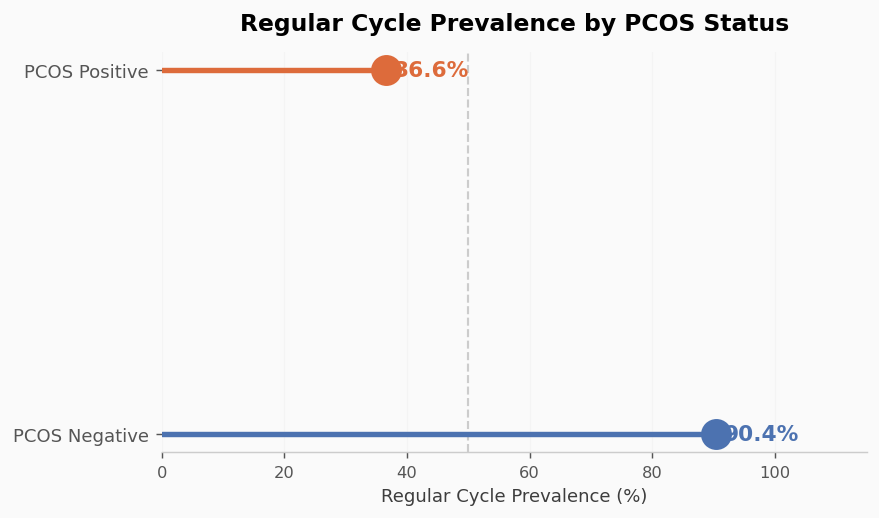

In [6]:
summary_q04 = grouped_binary_prevalence(df, "cycle_regularity")
display(summary_q04)

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#FAFAFA")

for i, row in summary_q04.iterrows():
    color = PCOS_LABEL_PALETTE[row["pcos_label"]]
    ax.plot([0, row["prevalence_pct"]], [i, i], color=color, lw=3, solid_capstyle="round")
    ax.scatter(row["prevalence_pct"], i, color=color, s=260, zorder=5)
    ax.text(row["prevalence_pct"] + 1.2, i, f"{row['prevalence_pct']:.1f}%",
            va="center", fontsize=12, fontweight="bold", color=color)

ax.axvline(50, color="#cccccc", lw=1.2, ls="--", zorder=0)
ax.set_yticks(range(len(summary_q04)))
ax.set_yticklabels(summary_q04["pcos_label"], fontsize=10)
ax.set_xlabel("Regular Cycle Prevalence (%)", fontsize=10)
ax.set_xlim(0, 115)
ax.set_title("Regular Cycle Prevalence by PCOS Status", fontsize=13, fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

save_fig(fig, "q04_cycle_regularity_prevalence.png")
plt.show()

### Insight
**Scientific interpretation:** The lollipop prevalence chart shows a very large drop in regular-cycle reporting for the PCOS-positive group, with the two groups separating far more than they do on age. This makes cycle regularity one of the strongest single survey features.

**Simple summary:** Regular cycles are much less common in the PCOS-positive survey group.

**Why this matters:** A simple cycle-regularity question appears highly valuable for non-invasive screening and outside-style validation.


---
## Q5 — Cycle Length by PCOS Status
**Chart type: Sina plot (KDE-shaped jittered scatter)**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,32.893,30.0,10.881,30,90
1,PCOS Positive,101,50.198,30.0,23.663,30,90


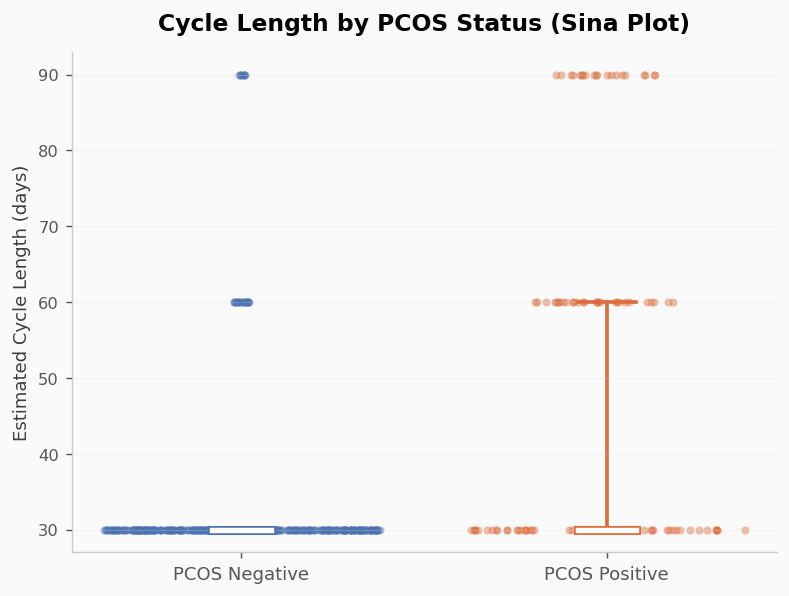

In [7]:
summary_q05 = grouped_numeric_summary(df, "cycle_length_days")
display(summary_q05)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#FAFAFA")

positions = {"PCOS Negative": 0, "PCOS Positive": 1}
colors_map = PCOS_LABEL_PALETTE

for label in PCOS_LABEL_ORDER:
    subset = df.loc[df["pcos_label"] == label, "cycle_length_days"].dropna().values
    pos = positions[label]
    color = colors_map[label]

    # Compute local KDE width to shape jitter (sina style)
    kde = gaussian_kde(subset, bw_method=0.35)
    kde_at_point = kde(subset)
    kde_at_point = kde_at_point / kde_at_point.max()
    jitter = np.random.uniform(-1, 1, size=len(subset)) * kde_at_point * 0.38

    ax.scatter(pos + jitter, subset, color=color, alpha=0.45, s=20, linewidths=0)

    # Overlay IQR bar and median
    q1, med, q3 = np.percentile(subset, [25, 50, 75])
    ax.plot([pos - 0.08, pos + 0.08], [q1, q1], color=color, lw=2)
    ax.plot([pos - 0.08, pos + 0.08], [q3, q3], color=color, lw=2)
    ax.plot([pos - 0.08, pos + 0.08], [med, med], color="white", lw=3,
            path_effects=[pe.withStroke(linewidth=5, foreground=color)])
    ax.plot([pos, pos], [q1, q3], color=color, lw=2, zorder=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(PCOS_LABEL_ORDER, fontsize=10)
ax.set_ylabel("Estimated Cycle Length (days)", fontsize=10)
ax.set_title("Cycle Length by PCOS Status (Sina Plot)", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

save_fig(fig, "q05_cycle_length_vs_pcos_survey.png")
plt.show()

### Insight
**Scientific interpretation:** The cycle-length distribution shifts upward in the PCOS-positive group, and the sina-style spread shows that longer values are not limited to a few outliers. Instead, more of the positive group is concentrating at extended cycle lengths.

**Simple summary:** PCOS-positive respondents tend to report longer cycles.

**Why this matters:** Cycle length is a clinically useful self-reported feature and looks substantially stronger than age in this survey setting.


---
## Q6 — Months Between Periods
**Chart type: Annotated ECDF with shaded separation band**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,1.096,1.0,0.363,1,3
1,PCOS Positive,101,1.673,1.0,0.789,1,3


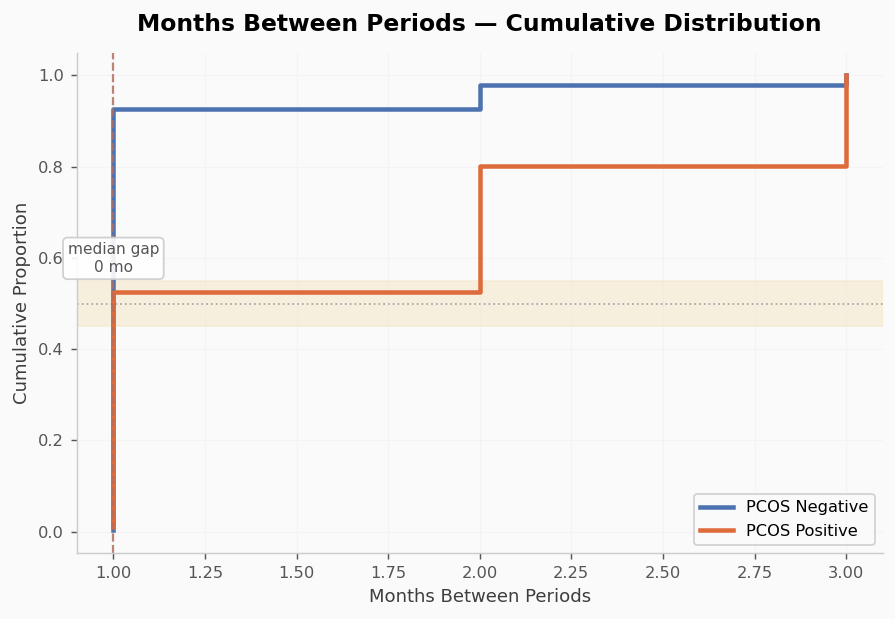

In [8]:
summary_q06 = grouped_numeric_summary(df, "months_between_periods")
display(summary_q06)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#FAFAFA")

ecdf_data = {}
for label in PCOS_LABEL_ORDER:
    subset = np.sort(df.loc[df["pcos_label"] == label, "months_between_periods"].dropna().values)
    ecdf_y = np.arange(1, len(subset) + 1) / len(subset)
    color = PCOS_LABEL_PALETTE[label]
    ax.step(subset, ecdf_y, where="post", color=color, lw=2.5, label=label)
    ecdf_data[label] = (subset, ecdf_y)

# Shade the gap between the two ECDFs at the median
neg_subset, neg_ecdf = ecdf_data["PCOS Negative"]
pos_subset, pos_ecdf = ecdf_data["PCOS Positive"]
# Find x where neg ECDF crosses 0.5
neg_med_x = neg_subset[np.searchsorted(neg_ecdf, 0.5)]
pos_med_x = pos_subset[np.searchsorted(pos_ecdf, 0.5)]
ax.axvline(neg_med_x, color=NEG_COLOR, lw=1.2, ls="--", alpha=0.6)
ax.axvline(pos_med_x, color=POS_COLOR, lw=1.2, ls="--", alpha=0.6)
ax.axhspan(0.45, 0.55, color="#f5e6c8", alpha=0.55, zorder=0)
ax.text((neg_med_x + pos_med_x) / 2, 0.57,
        f"median gap\n{pos_med_x - neg_med_x:.0f} mo",
        ha="center", fontsize=8.5, color="#555",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ccc", alpha=0.9))

ax.axhline(0.5, color="#aaa", lw=1, ls=":", zorder=0)
ax.set_xlabel("Months Between Periods", fontsize=10)
ax.set_ylabel("Cumulative Proportion", fontsize=10)
ax.set_title("Months Between Periods — Cumulative Distribution", fontsize=13, fontweight="bold")
ax.legend(frameon=True, loc="lower right")
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

save_fig(fig, "q06_months_between_periods_vs_pcos.png")
plt.show()

### Insight
**Scientific interpretation:** The ECDF curves show that the PCOS-positive group accumulates more slowly across months between periods, which is another way of saying that longer inter-period spacing is more common in that group. The percentile shift is therefore visible across the distribution rather than at only one summary point.

**Simple summary:** PCOS-positive respondents tend to wait longer between periods.

**Why this matters:** This adds a second menstrual-timing feature that supports the same underlying cycle-disruption story seen in the clinical data.


---
## Q7 — Period Duration by PCOS Status
**Chart type: Split half-violin (mirrored)**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,4.526,5.0,1.229,1.0,10.0
1,PCOS Positive,101,4.970,5.0,2.216,1.0,15.0


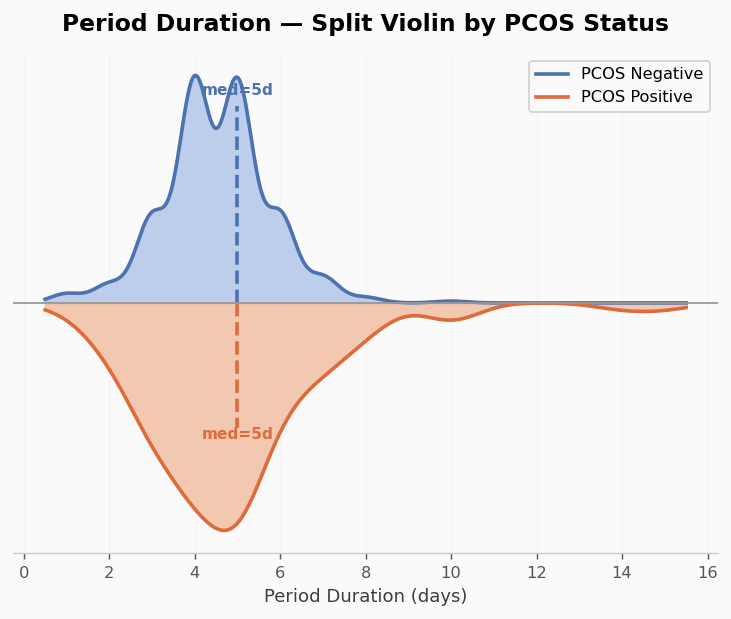

In [9]:
summary_q07 = grouped_numeric_summary(df, "period_duration_days")
display(summary_q07)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#FAFAFA")

feature = "period_duration_days"
x_min = df[feature].min() - 0.5
x_max = df[feature].max() + 0.5
x_range = np.linspace(x_min, x_max, 400)

for label, sign, color, lcolor in [
    ("PCOS Negative",  1, NEG_COLOR, NEG_LIGHT),
    ("PCOS Positive", -1, POS_COLOR, POS_LIGHT),
]:
    subset = df.loc[df["pcos_label"] == label, feature].dropna().values
    kde = gaussian_kde(subset, bw_method=0.3)
    kde_vals = kde(x_range)
    kde_vals = kde_vals / kde_vals.max() * 0.42
    ax.fill_between(x_range, 0, sign * kde_vals, color=lcolor, alpha=0.75)
    ax.plot(x_range, sign * kde_vals, color=color, lw=2, label=label)

    # Median tick
    med = np.median(subset)
    ax.plot([med, med], [0, sign * kde(np.array([med]))[0] / kde_vals.max() * 0.42],
            color=color, lw=2, ls="--")
    ax.text(med, sign * (kde(np.array([med]))[0] / kde_vals.max() * 0.42 + 0.02),
            f"med={med:.0f}d", ha="center", fontsize=8.5, color=color, fontweight="bold")

ax.axhline(0, color="#999", lw=1)
ax.set_xlabel("Period Duration (days)", fontsize=10)
ax.set_yticks([])
ax.set_title("Period Duration — Split Violin by PCOS Status", fontsize=13, fontweight="bold")
ax.legend(frameon=True, loc="upper right")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

save_fig(fig, "q07_period_duration_vs_pcos.png")
plt.show()

### Insight
**Scientific interpretation:** The mirrored density plot for period duration shows only modest separation, with strong overlap between the two groups despite a slight shift in the positive distribution. Compared with cycle spacing, duration itself appears much less distinctive.

**Simple summary:** How long the period lasts matters less here than how irregularly it comes.

**Why this matters:** This helps narrow later feature selection toward the most informative menstrual questions instead of treating every cycle-related variable as equally strong.


### Section Synthesis
**Cross-chart reading:** Age contributes almost no separation, BMI gives a moderate rightward shift, and the strongest survey differences are concentrated in cycle regularity and cycle spacing rather than period duration.

**How the findings relate:** This is closely aligned with the clinical story, where menstrual-pattern disruption is much more informative than simple demographic context.

**Practical interpretation:** For survey-based screening, cycle questions and BMI should be treated as core inputs, while age and period duration remain secondary.


---
## Q8–Q12 — Five Binary Symptom Prevalences
**Chart type: Grouped dot-matrix heatmap panel (all five symptoms side by side)**


pcos_label,PCOS Negative,PCOS Positive,Δ (pos−neg)
symptom,,,
Excess Hair Growth,19.0,53.5,34.5
Hair Loss,58.7,73.3,14.6
Pimples / Acne,38.0,52.5,14.5
Skin Darkening,27.8,54.5,26.7
Weight Gain,45.2,67.3,22.1


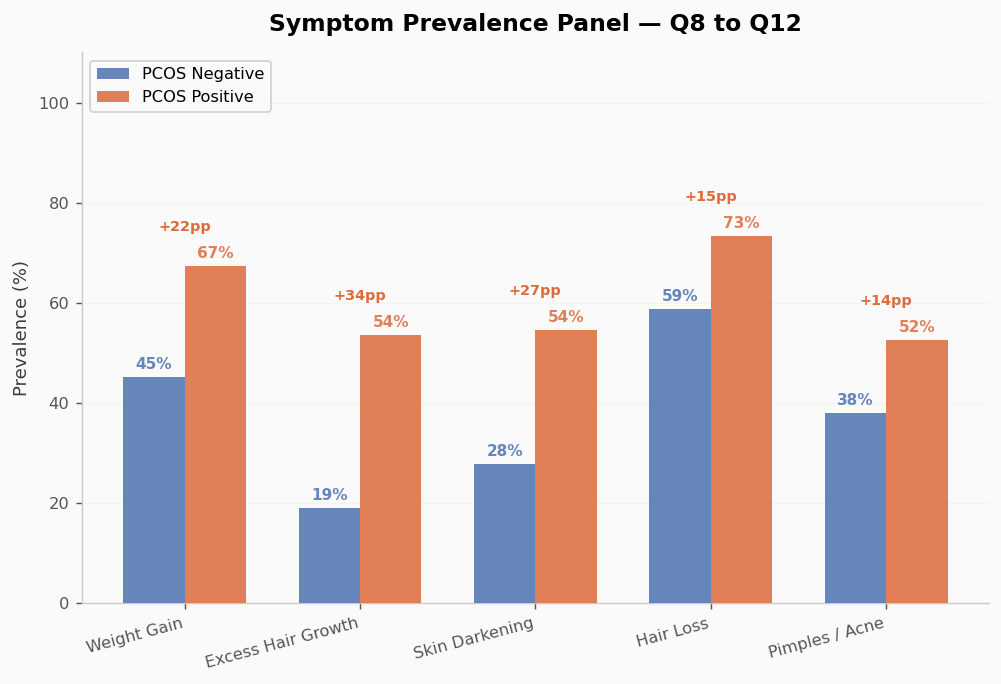

In [10]:
symptom_features = {
    "weight_gain_y_n":    "Weight Gain",
    "hair_growth_y_n":    "Excess Hair Growth",
    "skin_darkening_y_n": "Skin Darkening",
    "hair_loss_y_n":      "Hair Loss",
    "pimples_y_n":        "Pimples / Acne",
}

# Build a tidy summary
rows = []
for col, label in symptom_features.items():
    s = grouped_binary_prevalence(df, col)
    s["symptom"] = label
    rows.append(s)
sym_df = pd.concat(rows, ignore_index=True)

# Pivot for display
pivot = sym_df.pivot(index="symptom", columns="pcos_label", values="prevalence_pct")
pivot["Δ (pos−neg)"] = pivot["PCOS Positive"] - pivot["PCOS Negative"]
display(pivot.round(1))

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("#FAFAFA")

symptom_labels = list(symptom_features.values())
x = np.arange(len(symptom_labels))
width = 0.35

neg_vals = [pivot.loc[s, "PCOS Negative"] for s in symptom_labels]
pos_vals = [pivot.loc[s, "PCOS Positive"] for s in symptom_labels]

bars_neg = ax.bar(x - width / 2, neg_vals, width, color=NEG_COLOR,
                  alpha=0.85, label="PCOS Negative", zorder=3)
bars_pos = ax.bar(x + width / 2, pos_vals, width, color=POS_COLOR,
                  alpha=0.85, label="PCOS Positive", zorder=3)

for bar in list(bars_neg) + list(bars_pos):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
            f"{h:.0f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold",
            color=bar.get_facecolor())

# Delta annotation
for i, s in enumerate(symptom_labels):
    delta = pivot.loc[s, "Δ (pos−neg)"]
    y_top = max(neg_vals[i], pos_vals[i]) + 7
    arrow_color = POS_COLOR if delta > 0 else NEG_COLOR
    ax.annotate(f"+{delta:.0f}pp" if delta > 0 else f"{delta:.0f}pp",
                xy=(i, y_top), ha="center", fontsize=8, color=arrow_color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(symptom_labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Prevalence (%)", fontsize=10)
ax.set_ylim(0, 110)
ax.set_title("Symptom Prevalence Panel — Q8 to Q12", fontsize=13, fontweight="bold")
ax.legend(frameon=True, loc="upper left")
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

save_fig(fig, "q08_to_q12_symptom_panel.png")
plt.show()

### Insight
**Scientific interpretation:** The grouped symptom panel makes it easy to compare positive-minus-negative gaps directly, and the strongest differences are appearing for weight gain, hair growth, and skin darkening. Hair loss and pimples still move in the expected direction, but with more moderate separation.

**Simple summary:** The strongest symptom signals in the survey are weight gain, hair growth, and skin darkening.

**Why this matters:** These are high-value non-invasive questions because respondents can report them directly without laboratory testing.


---
## Q13–Q15 — Lifestyle and Mood
**Chart type: Diverging horizontal butterfly chart (Negative ← | → Positive)**


,pcos_label,n,positive_count,prevalence_pct,feature
0,PCOS Negative,363,124,34.2,Fast Food Consumption
1,PCOS Positive,101,42,41.6,Fast Food Consumption
2,PCOS Negative,363,105,28.9,Regular Exercise
3,PCOS Positive,101,27,26.7,Regular Exercise
4,PCOS Negative,363,267,73.6,Mood Swings
5,PCOS Positive,101,86,85.1,Mood Swings


C:\Users\USER\AppData\Local\Temp\ipykernel_6236\3618025192.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(t))}%" for t in xticks])


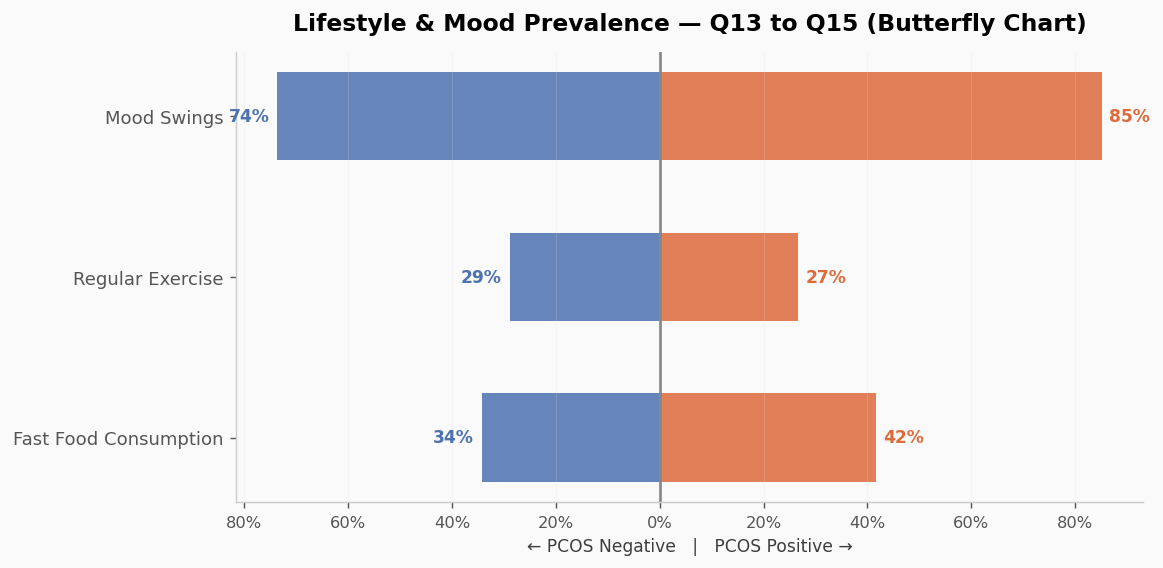

In [11]:
lifestyle_features = {
    "fast_food_y_n":       "Fast Food Consumption",
    "regular_exercise_y_n": "Regular Exercise",
    "mood_swings_y_n":     "Mood Swings",
}

rows_ls = []
for col, label in lifestyle_features.items():
    s = grouped_binary_prevalence(df, col)
    s["feature"] = label
    rows_ls.append(s)
ls_df = pd.concat(rows_ls, ignore_index=True)
display(ls_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("#FAFAFA")

feat_labels = list(lifestyle_features.values())
y = np.arange(len(feat_labels))

for i, feat in enumerate(feat_labels):
    neg_val = ls_df.loc[(ls_df["feature"] == feat) & (ls_df["pcos_label"] == "PCOS Negative"), "prevalence_pct"].values[0]
    pos_val = ls_df.loc[(ls_df["feature"] == feat) & (ls_df["pcos_label"] == "PCOS Positive"), "prevalence_pct"].values[0]

    # Negative bar goes left
    ax.barh(i, -neg_val, color=NEG_COLOR, alpha=0.85, height=0.55)
    ax.text(-neg_val - 1.5, i, f"{neg_val:.0f}%", va="center", ha="right",
            fontsize=9.5, fontweight="bold", color=NEG_COLOR)

    # Positive bar goes right
    ax.barh(i,  pos_val, color=POS_COLOR, alpha=0.85, height=0.55)
    ax.text(pos_val + 1.5, i, f"{pos_val:.0f}%", va="center", ha="left",
            fontsize=9.5, fontweight="bold", color=POS_COLOR)

ax.set_yticks(y)
ax.set_yticklabels(feat_labels, fontsize=10)
ax.axvline(0, color="#888", lw=1.5)

# Relabel x-axis with absolute values
xticks = ax.get_xticks()
ax.set_xticklabels([f"{abs(int(t))}%" for t in xticks])
ax.set_xlabel("← PCOS Negative   |   PCOS Positive →", fontsize=9.5)
ax.set_title("Lifestyle & Mood Prevalence — Q13 to Q15 (Butterfly Chart)",
             fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

save_fig(fig, "q13_to_q15_lifestyle_butterfly.png")
plt.show()

### Insight
**Scientific interpretation:** The butterfly chart shows that mood swings diverge more clearly than the lifestyle variables, while fast-food intake and regular exercise remain relatively close between groups. This suggests that subjective symptom burden is more informative here than broad behaviour proxies.

**Simple summary:** Mood swings show some signal, but fast food and exercise are weak compared with the main symptom questions.

**Why this matters:** Not every self-reported variable deserves equal weight, and lifestyle proxies should be interpreted cautiously because they are easily factor that can distort the comparisoned.


### Section Synthesis
**Cross-chart reading:** The survey symptom panel is preserving the same broad pattern seen clinically: visible androgenic and metabolic symptoms separate better than generic lifestyle behaviour.

**How the findings relate:** When combined with the earlier menstrual findings, the survey is still telling a coherent non-invasive PCOS story despite weaker measurement precision.

**Practical interpretation:** This supports using symptom and cycle questions as the backbone of outside-style validation, while treating behavioural features as supporting context.


---
## Q16 — Non-Invasive Burden Score
**Chart type: Filled KDE area chart with per-group mode and median callouts**


,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,363,3.036,3.0,1.644,0,8
1,PCOS Positive,101,4.792,5.0,1.663,1,8


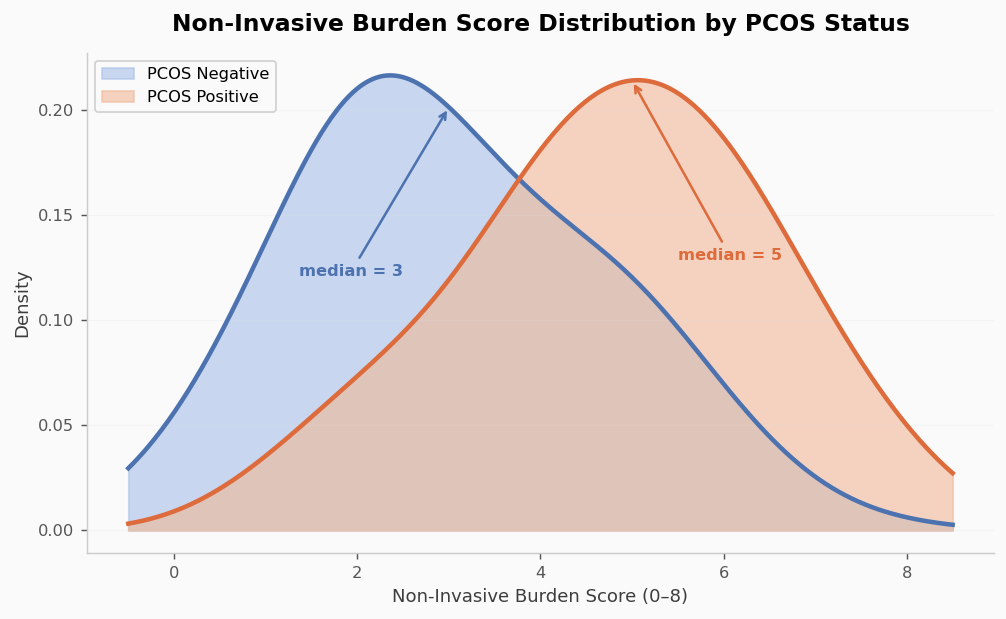

In [12]:
summary_q16 = grouped_numeric_summary(df, "non_invasive_burden_score")
display(summary_q16)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FAFAFA")

score_vals = sorted(df["non_invasive_burden_score"].dropna().unique())
x_smooth = np.linspace(min(score_vals) - 0.5, max(score_vals) + 0.5, 500)

for label, color, lcolor in [
    ("PCOS Negative", NEG_COLOR, NEG_LIGHT),
    ("PCOS Positive", POS_COLOR, POS_LIGHT),
]:
    subset = df.loc[df["pcos_label"] == label, "non_invasive_burden_score"].dropna().values
    kde = gaussian_kde(subset, bw_method=0.5)
    kde_vals = kde(x_smooth)
    ax.fill_between(x_smooth, 0, kde_vals, color=lcolor, alpha=0.6, label=label)
    ax.plot(x_smooth, kde_vals, color=color, lw=2.5)

    med = np.median(subset)
    med_density = kde(np.array([med]))[0]
    ax.annotate(
        f"median = {med:.0f}",
        xy=(med, med_density),
        xytext=(med + (0.5 if label == "PCOS Positive" else -0.5),
                med_density * 0.6),
        fontsize=9, color=color, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=color, lw=1.4),
        ha="left" if label == "PCOS Positive" else "right",
    )

ax.set_xlabel("Non-Invasive Burden Score (0–8)", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Non-Invasive Burden Score Distribution by PCOS Status",
             fontsize=13, fontweight="bold")
ax.legend(frameon=True, loc="upper left")
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

save_fig(fig, "q16_survey_burden_score.png")
plt.show()

### Insight
**Scientific interpretation:** The filled KDE curves show the composite burden score shifting to the right in the PCOS-positive group, meaning that higher counts of routine non-invasive indicators are concentrating more often among positive respondents. The overlap is still present, but the modal mass is clearly displaced.

**Simple summary:** People in the PCOS-positive survey group tend to accumulate more symptoms at the same time.

**Why this matters:** Composite non-invasive scores can be especially useful in noisy survey data because they reduce dependence on any single imperfect question.


### Section Synthesis
**Cross-chart reading:** The burden score pulls together the earlier BMI, menstrual, and symptom findings and still separates the groups even under self-report noise.

**How the findings relate:** This means the survey dataset is not replacing clinical evidence, but it is reproducing the same core non-invasive phenotype in a more realistic community-style setting.

**Practical interpretation:** The survey table is therefore well suited for portability checks and outside-style validation, provided its greater noise and class imbalance are kept explicit.


---
## Generalisation and Data-Quality Summary

**Observational summary:** The survey notebook is showing that the strongest self-reported PCOS signals come from cycle irregularity, longer cycle spacing, months between periods, BMI, weight gain, hair growth, skin darkening, and the composite burden score. Age, period duration, fast-food behaviour, and regular exercise remain much weaker or more factor that can distort the comparisoned.

**Simple wrap-up:** In plain language, the survey data is noisier than the clinical data, but the same main pattern is still visible: respondents with PCOS report more menstrual disruption and more symptom burden.

**Feature usefulness interpretation:**
**Stronger survey features:** `cycle_regularity`, `cycle_length_days`, `months_between_periods`, `bmi`, `weight_gain_y_n`, `hair_growth_y_n`, `skin_darkening_y_n`, `non_invasive_burden_score`
**Moderate survey features:** `pimples_y_n`, `hair_loss_y_n`, `mood_swings_y_n`, `period_duration_days`
**Weak or noisy survey features:** `age_yrs`, `fast_food_y_n`, `regular_exercise_y_n`
**Study positioning:** This notebook helps outside-style generalisation checks for non-invasive PCOS screening, not replacing the cleaned clinical cohort.
